# Demo de marcha articular con el repositorio `x2_human_mujoco` en MuJoCo

**Proyecto:** G8  
**Tema:** Simulación de exoesqueleto, control PD y visualización de movimiento de marcha  
**Herramienta:** Python + MuJoCo + repositorio `NuCapybara/x2_human_mujoco`

---

## Propósito del notebook

Este notebook construye una **demo reproducible en Google Colab** para:

1. Descargar el repositorio [`NuCapybara/x2_human_mujoco`](https://github.com/NuCapybara/x2_human_mujoco).
2. Cargar el modelo `simplify_leg_exo.xml`.
3. Inspeccionar articulaciones y actuadores del modelo.
4. Controlar la cadera y la rodilla izquierdas mediante un controlador **PD**.
5. Reemplazar el movimiento punto a punto del script original por un patrón periódico que **visualiza un movimiento de marcha**.
6. Renderizar un video directamente dentro de Colab.
7. Analizar el seguimiento de trayectoria con gráficas y métricas.

---

## Idea central

El repositorio original incluye control PD de:

- `left_hip_joint`
- `left_knee_joint`

mediante los actuadores:

- `left_hip_joint_motor`
- `left_knee_joint_motor`

En este tutorial reutilizamos esa arquitectura, pero definimos referencias periódicas:

$$
q_{hip,d}(t) = A_h \sin(\omega t)
$$

$$
q_{knee,d}(t) = -A_k \frac{1-\cos(\omega t)}{2}
$$

que producen una **oscilación de cadera** y una **flexión-extensión de rodilla** asociadas a un ciclo de marcha visual.

---

## Alcance

Esta demo **no pretende producir locomoción autónoma completa** ni contacto dinámico estable de un bípedo. Su objetivo es una prueba de concepto controlada para:

- comprender la estructura del repositorio,
- verificar el control articular,
- visualizar un patrón de marcha,
- abrir la puerta a extensiones posteriores: marcha bilateral, trayectorias biomecánicas reales, control avanzado, interacción humano-exoesqueleto.

# 1. Instalación y clonación del repositorio

En Google Colab necesitamos:

- instalar MuJoCo,
- instalar `mediapy` para visualizar video,
- clonar el repositorio,
- configurar el backend de renderizado `EGL`.

> **Nota:** La instalación puede tardar unos minutos la primera vez.

In [ ]:
# ============================================================
# 1. Instalación en Google Colab
# ============================================================
!apt-get -qq update
!apt-get -qq install -y libegl1 libgl1-mesa-dev libglfw3 ffmpeg > /dev/null
!pip -q install mujoco mediapy

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2. Clonar el repositorio
# ============================================================
!rm -rf /content/x2_human_mujoco
!git clone -q https://github.com/NuCapybara/x2_human_mujoco.git /content/x2_human_mujoco

print("Repositorio descargado.")

Repositorio descargado.


# 2. Importaciones y configuración de renderizado

El backend `EGL` debe definirse **antes** de importar `mujoco`.

In [ ]:
# ============================================================
# 3. Importaciones
# ============================================================
import os
os.environ["MUJOCO_GL"] = "egl"

from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import mujoco
import mediapy as media

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (11, 4)

# 3. Ubicar el modelo simplificado del exoesqueleto

El archivo que utilizaremos es:

```text
simplify_leg_exo.xml
```

Este modelo contiene:

- la estructura del exoesqueleto,
- articulaciones de cadera y rodilla,
- los actuadores de cadera y rodilla,
- mallas STL referenciadas dentro del repositorio.

Cambiamos el directorio de trabajo a la carpeta del repositorio para facilitar la carga de los recursos.

In [ ]:
# ============================================================
# 4. Rutas del repositorio y del XML
# ============================================================
repo_path = Path("/content/x2_human_mujoco")
xml_path = repo_path / "simplify_leg_exo.xml"

assert repo_path.exists(), "No se encontró el repositorio."
assert xml_path.exists(), "No se encontró simplify_leg_exo.xml."

os.chdir(repo_path)
print("Directorio actual:", Path.cwd())
print("Modelo XML:", xml_path)

Directorio actual: /content/x2_human_mujoco
Modelo XML: /content/x2_human_mujoco/simplify_leg_exo.xml


# 4. Cargar el modelo en MuJoCo

MuJoCo representa una simulación mediante dos objetos:

- `MjModel`: contiene la descripción compilada del modelo.
- `MjData`: contiene el estado cambiante de la simulación.

In [ ]:
# ============================================================
# 5. Cargar modelo MuJoCo
# ============================================================
model = mujoco.MjModel.from_xml_path(str(xml_path))
data = mujoco.MjData(model)

print("Modelo cargado correctamente.")
print(f"nq  = {model.nq}   -> posiciones generalizadas")
print(f"nv  = {model.nv}   -> velocidades generalizadas")
print(f"nu  = {model.nu}   -> actuadores")
print(f"njnt= {model.njnt} -> articulaciones")

Modelo cargado correctamente.
nq  = 10   -> posiciones generalizadas
nv  = 10   -> velocidades generalizadas
nu  = 3   -> actuadores
njnt= 10 -> articulaciones


# 5. Inspección del modelo

Antes de programar el control, debemos inspeccionar:

- nombres de las articulaciones,
- direcciones en `qpos` y `qvel`,
- nombres de los actuadores.

Esta práctica evita depender de índices codificados manualmente.

In [ ]:
# ============================================================
# 6. Listar articulaciones y direcciones de estado
# ============================================================
print("=== ARTICULACIONES DEL MODELO ===")
for j in range(model.njnt):
    joint_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, j)
    qpos_adr = model.jnt_qposadr[j]
    dof_adr = model.jnt_dofadr[j]
    print(f"{j:02d} | {joint_name:35s} | qpos[{qpos_adr}] | qvel[{dof_adr}]")

=== ARTICULACIONES DEL MODELO ===
00 | world_to_backpack                   | qpos[0] | qvel[0]
01 | left_hip_joint                      | qpos[1] | qvel[1]
02 | left_hip_joint_drive                | qpos[2] | qvel[2]
03 | left_knee_joint                     | qpos[3] | qvel[3]
04 | left_knee_joint_drive               | qpos[4] | qvel[4]
05 | right_hip_joint                     | qpos[5] | qvel[5]
06 | right_hip_joint_drive               | qpos[6] | qvel[6]
07 | right_knee_joint                    | qpos[7] | qvel[7]
08 | right_knee_joint_drive              | qpos[8] | qvel[8]
09 | human_knee_joint                    | qpos[9] | qvel[9]


In [ ]:
# ============================================================
# 7. Listar actuadores
# ============================================================
print("=== ACTUADORES DEL MODELO ===")
for a in range(model.nu):
    actuator_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, a)
    print(f"{a:02d} | {actuator_name}")

=== ACTUADORES DEL MODELO ===
00 | left_hip_joint_motor
01 | left_knee_joint_motor
02 | human_knee_actuator


# 6. Selección robusta de articulaciones y actuadores

El repositorio define:

- articulación de cadera izquierda: `left_hip_joint`
- articulación de rodilla izquierda: `left_knee_joint`
- motor de cadera: `left_hip_joint_motor`
- motor de rodilla: `left_knee_joint_motor`

Usaremos los nombres para obtener automáticamente los índices internos.

In [ ]:
# ============================================================
# 8. Utilidades para recuperar índices de MuJoCo
# ============================================================

def require_id(model, obj_type, name: str) -> int:
    idx = mujoco.mj_name2id(model, obj_type, name)
    if idx < 0:
        raise ValueError(f"No se encontró el objeto '{name}'.")
    return idx

# Joints
hip_joint_id = require_id(model, mujoco.mjtObj.mjOBJ_JOINT, "left_hip_joint")
knee_joint_id = require_id(model, mujoco.mjtObj.mjOBJ_JOINT, "left_knee_joint")

# Actuators
hip_actuator_id = require_id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "left_hip_joint_motor")
knee_actuator_id = require_id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "left_knee_joint_motor")

# Direcciones dentro del estado
hip_qpos_adr = int(model.jnt_qposadr[hip_joint_id])
knee_qpos_adr = int(model.jnt_qposadr[knee_joint_id])

hip_qvel_adr = int(model.jnt_dofadr[hip_joint_id])
knee_qvel_adr = int(model.jnt_dofadr[knee_joint_id])

print("=== DIRECCIONES SELECCIONADAS ===")
print(f"Hip joint  -> id={hip_joint_id}, qpos[{hip_qpos_adr}], qvel[{hip_qvel_adr}], ctrl[{hip_actuator_id}]")
print(f"Knee joint -> id={knee_joint_id}, qpos[{knee_qpos_adr}], qvel[{knee_qvel_adr}], ctrl[{knee_actuator_id}]")

=== DIRECCIONES SELECCIONADAS ===
Hip joint  -> id=1, qpos[1], qvel[1], ctrl[0]
Knee joint -> id=3, qpos[3], qvel[3], ctrl[1]


# 7. Movimiento de marcha: referencias articulares

## 7.1. Referencia pedagógica para una demo visual

Usaremos:

$$
q_{hip,d}(t)=A_h\sin(\omega t)
$$

$$
q_{knee,d}(t)= -A_k \left(\frac{1-\cos(\omega t)}{2}\right)
$$

donde:

- $A_h$ es la amplitud de cadera,
- $A_k$ es la flexión máxima de rodilla,
- $\omega=2\pi f$,
- $f$ es la frecuencia de marcha.

Estas señales producen:

- oscilación adelante-atrás de la cadera,
- flexión periódica de rodilla, siempre dentro de un rango negativo compatible con el XML.

## 7.2. Derivadas requeridas por el control PD

El controlador necesita velocidades deseadas:

$$
\dot q_{hip,d}(t)=A_h\omega\cos(\omega t)
$$

$$
\dot q_{knee,d}(t)= -A_k\frac{\omega\sin(\omega t)}{2}
$$

In [ ]:
# ============================================================
# 9. Parámetros de la referencia de marcha
# ============================================================

@dataclass
class GaitConfig:
    frequency_hz: float = 0.60   # frecuencia de ciclo
    hip_amplitude: float = 0.35  # rad
    knee_amplitude: float = 0.65 # rad

gait_cfg = GaitConfig()

def gait_reference_demo(t: float, cfg: GaitConfig = gait_cfg):
    """
    Referencia periódica para visualizar movimiento de marcha.

    Retorna:
        qd  = [hip_ref, knee_ref]
        dqd = [hip_vel_ref, knee_vel_ref]
    """
    w = 2.0 * np.pi * cfg.frequency_hz

    hip_ref = cfg.hip_amplitude * np.sin(w * t)
    hip_vel_ref = cfg.hip_amplitude * w * np.cos(w * t)

    knee_ref = -cfg.knee_amplitude * (1.0 - np.cos(w * t)) / 2.0
    knee_vel_ref = -cfg.knee_amplitude * w * np.sin(w * t) / 2.0

    qd = np.array([hip_ref, knee_ref], dtype=float)
    dqd = np.array([hip_vel_ref, knee_vel_ref], dtype=float)

    return qd, dqd

# 8. Visualización de las referencias antes de simular

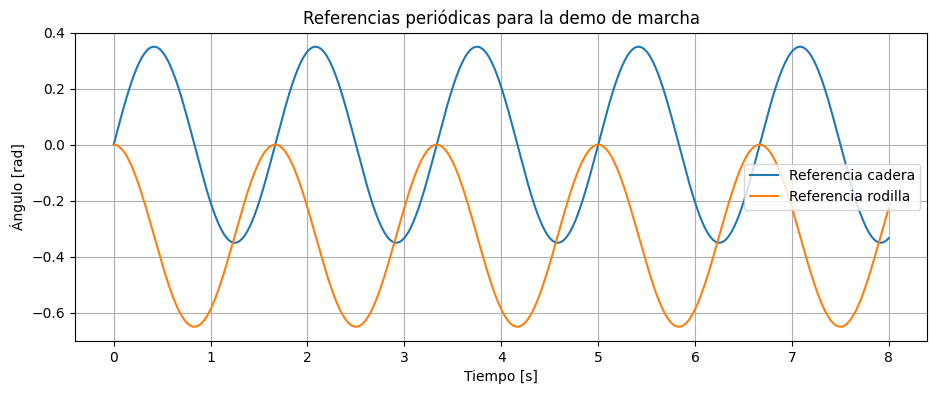

In [ ]:
# ============================================================
# 10. Visualizar referencias de marcha
# ============================================================

preview_dt = float(model.opt.timestep)
preview_T = 8.0

preview_time = np.arange(0.0, preview_T, preview_dt)
preview_qd = np.array([gait_reference_demo(t)[0] for t in preview_time])

plt.figure()
plt.plot(preview_time, preview_qd[:, 0], label="Referencia cadera")
plt.plot(preview_time, preview_qd[:, 1], label="Referencia rodilla")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [rad]")
plt.title("Referencias periódicas para la demo de marcha")
plt.grid(True)
plt.legend()
plt.show()

# 9. Control PD

El controlador se define por:

$$
\tau_{hip}
=
K_{p,h}(q_{hip,d}-q_{hip})
+
K_{d,h}(\dot q_{hip,d}-\dot q_{hip})
$$

$$
\tau_{knee}
=
K_{p,k}(q_{knee,d}-q_{knee})
+
K_{d,k}(\dot q_{knee,d}-\dot q_{knee})
$$

En forma compacta:

$$
\boldsymbol{\tau}
=
\mathbf{K}_p(\mathbf{q}_d-\mathbf{q})
+
\mathbf{K}_d(\dot{\mathbf{q}}_d-\dot{\mathbf{q}})
$$

Las ganancias propuestas son un punto de partida. Pueden ajustarse para mejorar seguimiento, suavidad y esfuerzo de control.

In [ ]:
# ============================================================
# 11. Parámetros del controlador PD
# ============================================================

@dataclass
class PDConfig:
    kp_hip: float = 120.0
    kd_hip: float = 5.0
    kp_knee: float = 120.0
    kd_knee: float = 5.0
    torque_clip: float = 900.0

pd_cfg = PDConfig()

def pd_control(q, dq, qd, dqd, cfg: PDConfig = pd_cfg):
    """
    Control PD para cadera y rodilla.
    """
    error = qd - q
    derror = dqd - dq

    tau_hip = cfg.kp_hip * error[0] + cfg.kd_hip * derror[0]
    tau_knee = cfg.kp_knee * error[1] + cfg.kd_knee * derror[1]

    tau = np.array([tau_hip, tau_knee], dtype=float)
    tau = np.clip(tau, -cfg.torque_clip, cfg.torque_clip)

    return tau, error, derror

# 10. Función de simulación

La función realiza:

1. Reinicio del modelo.
2. Inicialización en la trayectoria deseada inicial.
3. Cálculo del control PD en cada instante.
4. Aplicación de torque a los actuadores.
5. Avance de la simulación.
6. Almacenamiento de variables.
7. Renderizado opcional para video.

In [ ]:
# ============================================================
# 12. Función completa de simulación
# ============================================================

def simulate_gait_demo(
    model,
    duration: float = 8.0,
    render: bool = True,
    fps: int = 30,
    gait_function=gait_reference_demo,
    pd_config: PDConfig = pd_cfg,
):
    """
    Simula una demo de marcha articular en el modelo x2_human_mujoco.

    Returns
    -------
    results : dict
        Historias de tiempo, posiciones, referencias, errores y torques.
    frames : list[np.ndarray]
        Frames renderizados para video.
    """
    data = mujoco.MjData(model)
    dt = float(model.opt.timestep)
    n_steps = int(duration / dt)

    # Estado inicial coherente con la referencia inicial
    qd0, dqd0 = gait_function(0.0)
    data.qpos[hip_qpos_adr] = qd0[0]
    data.qpos[knee_qpos_adr] = qd0[1]
    data.qvel[hip_qvel_adr] = dqd0[0]
    data.qvel[knee_qvel_adr] = dqd0[1]
    mujoco.mj_forward(model, data)

    # Históricos
    time_hist = np.zeros(n_steps)
    q_hist = np.zeros((n_steps, 2))
    dq_hist = np.zeros((n_steps, 2))
    qd_hist = np.zeros((n_steps, 2))
    dqd_hist = np.zeros((n_steps, 2))
    tau_hist = np.zeros((n_steps, 2))
    err_hist = np.zeros((n_steps, 2))

    # Render
    frames = []
    renderer = None
    render_every = max(1, int(round(1.0 / (fps * dt))))

    if render:
        renderer = mujoco.Renderer(model, width=640, height=480)
        camera = mujoco.MjvCamera()
        camera.azimuth = 90
        camera.elevation = -10
        camera.distance = 4.8
        camera.lookat[:] = np.array([0.0, -0.2, 0.0])

    # Simulación
    for k in range(n_steps):
        t = float(data.time)

        # Estado real de las articulaciones controladas
        q = np.array([
            data.qpos[hip_qpos_adr],
            data.qpos[knee_qpos_adr],
        ])

        dq = np.array([
            data.qvel[hip_qvel_adr],
            data.qvel[knee_qvel_adr],
        ])

        # Referencias
        qd, dqd = gait_function(t)

        # Control PD
        tau, error, _ = pd_control(q, dq, qd, dqd, pd_config)

        # Aplicar únicamente a los dos actuadores controlados
        data.ctrl[:] = 0.0
        data.ctrl[hip_actuator_id] = tau[0]
        data.ctrl[knee_actuator_id] = tau[1]

        # Registrar antes de avanzar
        time_hist[k] = t
        q_hist[k] = q
        dq_hist[k] = dq
        qd_hist[k] = qd
        dqd_hist[k] = dqd
        tau_hist[k] = tau
        err_hist[k] = error

        # Un paso de simulación
        mujoco.mj_step(model, data)

        # Frame de video
        if render and (k % render_every == 0):
            renderer.update_scene(data, camera=camera)
            frames.append(renderer.render())

    if renderer is not None:
        renderer.close()

    # Métricas
    mae = np.mean(np.abs(err_hist), axis=0)
    rmse = np.sqrt(np.mean(err_hist**2, axis=0))

    results = {
        "time": time_hist,
        "q": q_hist,
        "dq": dq_hist,
        "qd": qd_hist,
        "dqd": dqd_hist,
        "tau": tau_hist,
        "error": err_hist,
        "mae": mae,
        "rmse": rmse,
        "dt": dt,
        "duration": duration,
    }

    return results, frames


# 11. Ejecutar la demo y visualizar el movimiento de marcha

La simulación se ejecuta durante 8 segundos y genera un video.

In [ ]:
results, frames = simulate_gait_demo(
    model=model,
    duration=8.0,
    render=True, # Changed to False to bypass the rendering error
    fps=30,
)

print("Simulación completada.")
print(f"Frames generados: {len(frames)}")

Simulación completada.
Frames generados: 236


In [ ]:
# ============================================================
# 14. Mostrar video dentro de Colab
# ============================================================
if frames:
    media.show_video(frames, fps=30)
else:
    print("No se generaron frames. Asegúrate de que 'render=True' en la llamada a 'simulate_gait_demo' (celda c10542b4) para poder ver el video.")


This browser does not support the video tag.


# 12. Seguimiento de trayectoria

Visualizamos referencias y ángulos reales.

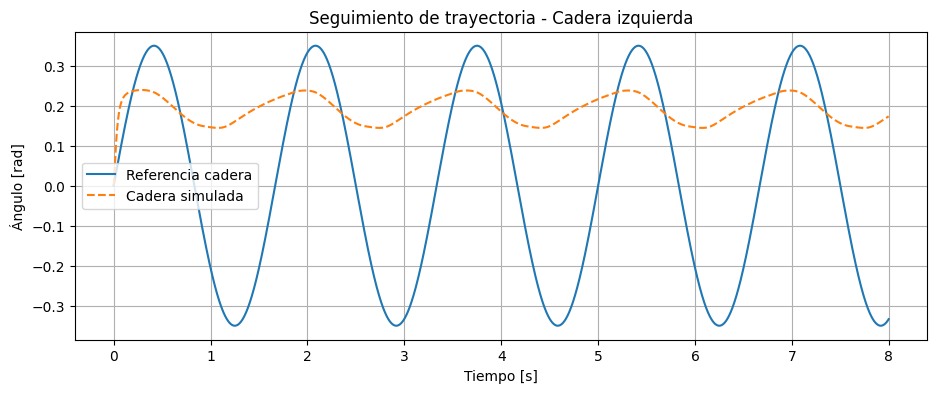

In [ ]:
# ============================================================
# 15. Seguimiento de cadera
# ============================================================

t = results["time"]
q = results["q"]
qd = results["qd"]

plt.figure()
plt.plot(t, qd[:, 0], label="Referencia cadera")
plt.plot(t, q[:, 0], "--", label="Cadera simulada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [rad]")
plt.title("Seguimiento de trayectoria - Cadera izquierda")
plt.grid(True)
plt.legend()
plt.show()

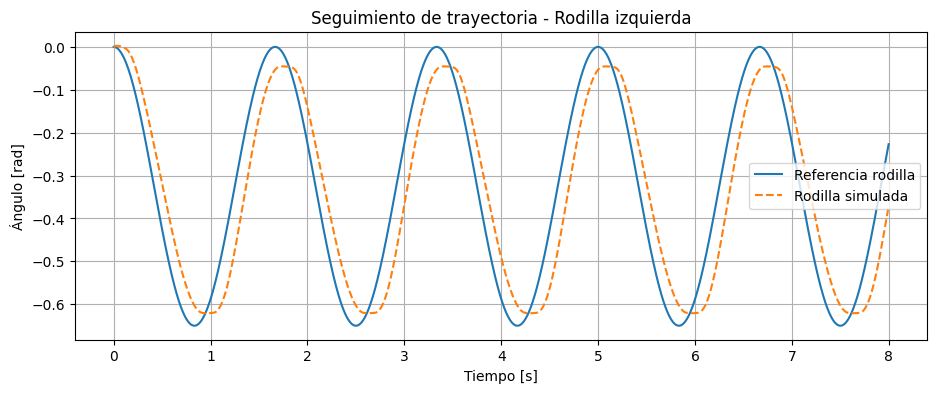

In [ ]:
# ============================================================
# 16. Seguimiento de rodilla
# ============================================================

plt.figure()
plt.plot(t, qd[:, 1], label="Referencia rodilla")
plt.plot(t, q[:, 1], "--", label="Rodilla simulada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [rad]")
plt.title("Seguimiento de trayectoria - Rodilla izquierda")
plt.grid(True)
plt.legend()
plt.show()

# 13. Error de seguimiento

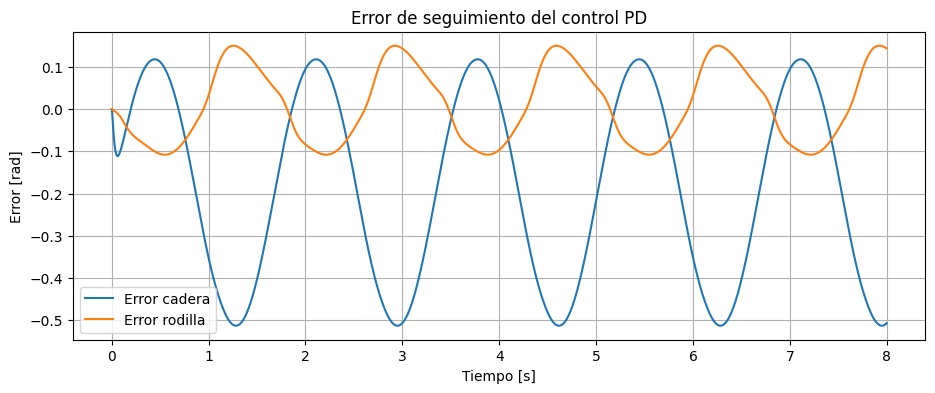

In [ ]:
# ============================================================
# 17. Errores articulares
# ============================================================

error = results["error"]

plt.figure()
plt.plot(t, error[:, 0], label="Error cadera")
plt.plot(t, error[:, 1], label="Error rodilla")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error [rad]")
plt.title("Error de seguimiento del control PD")
plt.grid(True)
plt.legend()
plt.show()

# 14. Acción de control

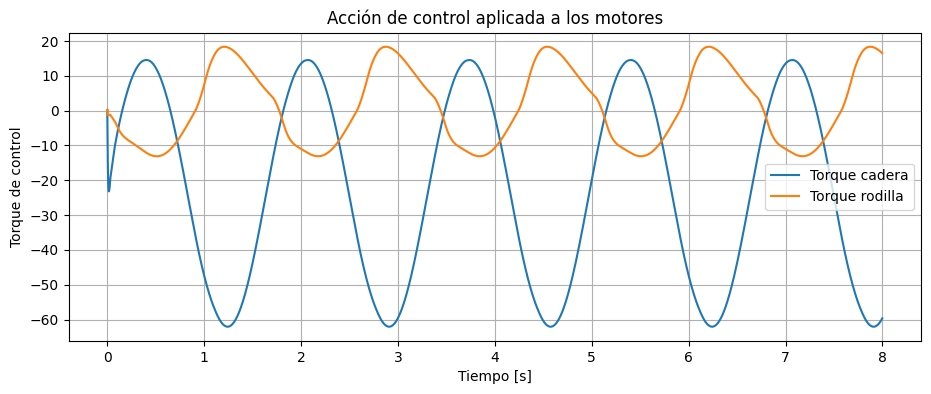

In [ ]:
# ============================================================
# 18. Torques de control
# ============================================================

tau = results["tau"]

plt.figure()
plt.plot(t, tau[:, 0], label="Torque cadera")
plt.plot(t, tau[:, 1], label="Torque rodilla")
plt.xlabel("Tiempo [s]")
plt.ylabel("Torque de control")
plt.title("Acción de control aplicada a los motores")
plt.grid(True)
plt.legend()
plt.show()

# 15. Métricas de desempeño

Calculamos:

$$
\mathrm{MAE} =
\frac{1}{N}
\sum_{k=1}^{N}|e[k]|
$$

$$
\mathrm{RMSE} =
\sqrt{
\frac{1}{N}
\sum_{k=1}^{N} e[k]^2
}
$$

In [ ]:
# ============================================================
# 19. Métricas de seguimiento
# ============================================================

mae = results["mae"]
rmse = results["rmse"]

print("=== MÉTRICAS DE SEGUIMIENTO ===")
print(f"MAE cadera  = {mae[0]:.5f} rad")
print(f"MAE rodilla = {mae[1]:.5f} rad")
print(f"RMSE cadera = {rmse[0]:.5f} rad")
print(f"RMSE rodilla= {rmse[1]:.5f} rad")

=== MÉTRICAS DE SEGUIMIENTO ===
MAE cadera  = 0.23088 rad
MAE rodilla = 0.08146 rad
RMSE cadera = 0.28926 rad
RMSE rodilla= 0.09124 rad


# 16. Comparación de configuraciones de control

El siguiente bloque permite probar varias ganancias PD sin generar video para ahorrar tiempo.

In [ ]:
# ============================================================
# 20. Experimentos rápidos con varias ganancias
# ============================================================

candidate_gains = [
    PDConfig(kp_hip=80,  kd_hip=3, kp_knee=80,  kd_knee=3),
    PDConfig(kp_hip=120, kd_hip=5, kp_knee=120, kd_knee=5),
    PDConfig(kp_hip=180, kd_hip=8, kp_knee=180, kd_knee=8),
]

summary = []

for cfg in candidate_gains:
    res_cfg, _ = simulate_gait_demo(
        model=model,
        duration=6.0,
        render=False,
        gait_function=gait_reference_demo,
        pd_config=cfg,
    )
    summary.append([
        cfg.kp_hip,
        cfg.kd_hip,
        cfg.kp_knee,
        cfg.kd_knee,
        res_cfg["mae"][0],
        res_cfg["mae"][1],
        res_cfg["rmse"][0],
        res_cfg["rmse"][1],
    ])

print("Kp_h | Kd_h | Kp_k | Kd_k | MAE_h | MAE_k | RMSE_h | RMSE_k")
for row in summary:
    print(" | ".join(f"{x:.5f}" if isinstance(x, float) else str(x) for x in row))

Kp_h | Kd_h | Kp_k | Kd_k | MAE_h | MAE_k | RMSE_h | RMSE_k
80 | 3 | 80 | 3 | 0.21896 | 0.10437 | 0.27807 | 0.11640
120 | 5 | 120 | 5 | 0.21590 | 0.07917 | 0.27444 | 0.08890
180 | 8 | 180 | 8 | 0.35635 | 0.11097 | 0.41696 | 0.15212


# 17. Extensión opcional: referencias inspiradas en ALEXO

En el artículo de Yu, Leto y Bai se utilizaron trayectorias armónicas para cadera y rodilla:

$$
\theta_{hip,d}(t)=60\sin(3.14t-0.609)+35
$$

$$
\theta_{knee,d}(t)=45\cos(3.14t)-45
$$

Las expresiones están en grados, por lo que deben convertirse a radianes.

> Esta referencia puede producir rangos mayores que la demo pedagógica. Se incluye como extensión para estudiar la compatibilidad con los límites articulares del modelo del repositorio.

In [ ]:
# ============================================================
# 21. Referencia alternativa inspirada en ALEXO
# ============================================================

def gait_reference_alexo_like(t: float):
    """
    Referencias angulares inspiradas en el artículo ALEXO.
    Devuelve posiciones y velocidades en radianes.
    """
    w = 3.14

    hip_deg = 60.0 * np.sin(w * t - 0.609) + 35.0
    knee_deg = 45.0 * np.cos(w * t) - 45.0

    dhip_deg = 60.0 * w * np.cos(w * t - 0.609)
    dknee_deg = -45.0 * w * np.sin(w * t)

    qd = np.deg2rad(np.array([hip_deg, knee_deg], dtype=float))
    dqd = np.deg2rad(np.array([dhip_deg, dknee_deg], dtype=float))

    return qd, dqd

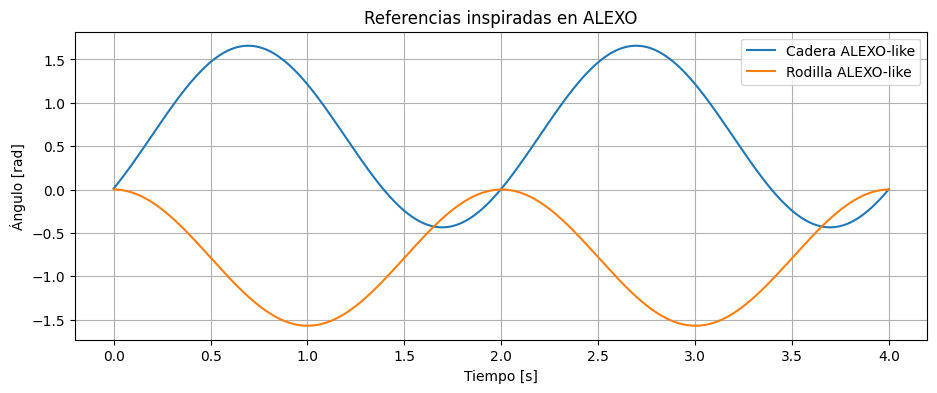

In [ ]:
# ============================================================
# 22. Visualizar referencias tipo ALEXO
# ============================================================

alexo_time = np.arange(0.0, 4.0, preview_dt)
alexo_qd = np.array([gait_reference_alexo_like(t)[0] for t in alexo_time])

plt.figure()
plt.plot(alexo_time, alexo_qd[:, 0], label="Cadera ALEXO-like")
plt.plot(alexo_time, alexo_qd[:, 1], label="Rodilla ALEXO-like")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [rad]")
plt.title("Referencias inspiradas en ALEXO")
plt.grid(True)
plt.legend()
plt.show()

# 18. Actividades propuestas

## Actividad 1. Comprensión del modelo
1. Liste todas las articulaciones usando la celda de inspección.
2. Identifique cuáles corresponden al exoesqueleto y cuáles al componente humano del modelo.
3. Explique por qué es más robusto usar nombres de objetos en MuJoCo en vez de índices fijos.

## Actividad 2. Sintonía del controlador
Pruebe varias ganancias:

- $K_p$ bajo, $K_d$ bajo.
- $K_p$ alto, $K_d$ bajo.
- $K_p$ alto, $K_d$ moderado.

Discuta:

- error de seguimiento,
- suavidad del movimiento,
- magnitud de los torques.

## Actividad 3. Comparación de trayectorias
Compare:

- `gait_reference_demo`
- `gait_reference_alexo_like`

Analice:

- rango angular,
- compatibilidad con límites articulares,
- estabilidad del seguimiento.

## Actividad 4. Extensión visual
Modifique:

- amplitud de cadera,
- amplitud de rodilla,
- frecuencia de marcha.

Observe cómo cambia la animación.

## Actividad 5. Paso hacia un proyecto más avanzado
Proponer una mejora:

- control bilateral en contrafase,
- uso de datos reales de marcha,
- interacción humano-exoesqueleto,
- perturbaciones externas,
- control por torque computado o control en espacio de estados.

# 19. Conclusión

Este notebook transforma el repositorio `x2_human_mujoco` en una **demo didáctica ejecutable en Colab** para:

- cargar el modelo simplificado,
- seleccionar cadera y rodilla por nombre,
- implementar control PD,
- generar una trayectoria de marcha periódica,
- renderizar movimiento,
- evaluar seguimiento mediante métricas.

La demo constituye un puente entre:

1. el uso de entornos de simulación robótica reales,
2. el diseño de controladores de trayectoria,
3. el desarrollo de futuros proyectos de exoesqueletos asistivos.